In [20]:
!pip install ucimlrepo xgboost scikit-learn pandas numpy matplotlib seaborn

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [22]:
!pip install kagglehub[pandas-datasets]

In [23]:



import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET_ID = "anlgrbz/student-demographics-online-education-dataoulad"

def load_oulad_file(filename):
    return kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET_ID,
        filename
    )

assessments        = load_oulad_file("assessments.csv")
courses             = load_oulad_file("courses.csv")
studentAssessment   = load_oulad_file("studentAssessment.csv")
studentInfo          = load_oulad_file("studentInfo.csv")
studentRegistration = load_oulad_file("studentRegistration.csv")
studentVle           = load_oulad_file("studentVle.csv")
vle                  = load_oulad_file("vle.csv")

print("Số dòng mỗi bảng OULAD:")
for name, df in [("assessments", assessments), ("courses", courses),
                  ("studentAssessment", studentAssessment), ("studentInfo", studentInfo),
                  ("studentRegistration", studentRegistration), ("studentVle", studentVle),
                  ("vle", vle)]:
    print(f"  {name:20s}: {df.shape}")

Số dòng mỗi bảng OULAD:
  assessments         : (206, 6)
  courses             : (22, 3)
  studentAssessment   : (173912, 5)
  studentInfo         : (32593, 12)
  studentRegistration : (32593, 5)
  studentVle          : (10655280, 6)
  vle                 : (6364, 6)


Phân bố kết quả học tập (final_result):
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


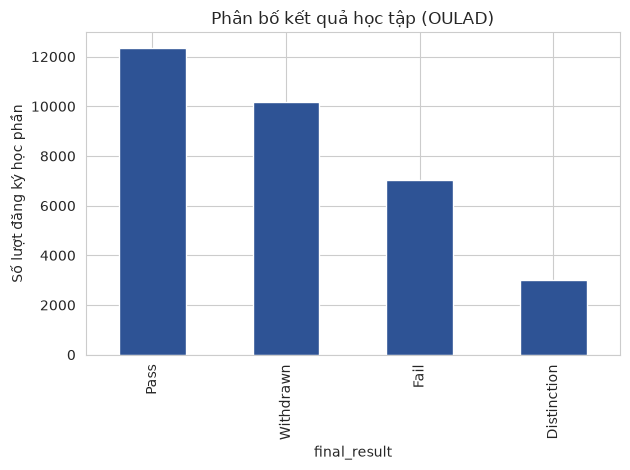


Số giá trị thiếu theo cột:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64


In [24]:
print("Phân bố kết quả học tập (final_result):")
print(studentInfo['final_result'].value_counts())

studentInfo['final_result'].value_counts().plot(kind='bar', title='Phân bố kết quả học tập (OULAD)', color='#2E5395')
plt.ylabel('Số lượt đăng ký học phần')
plt.tight_layout()
plt.show()

print("\nSố giá trị thiếu theo cột:")
print(studentInfo.isnull().sum())

In [25]:


# 3.1 Tổng số click trên VLE mỗi sinh viên trong mỗi lượt học -> đại diện mức độ tương tác LMS
vle_clicks = studentVle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index()
vle_clicks.rename(columns={'sum_click': 'total_clicks'}, inplace=True)

# 3.2 Điểm trung bình các bài đánh giá quá trình (TMA) -> đại diện "điểm giữa kỳ"
sa = studentAssessment.merge(assessments, on='id_assessment', how='left')
sa_tma = sa[sa['assessment_type'] == 'TMA']
midterm_scores = sa_tma.groupby(['id_student', 'code_module', 'code_presentation'])['score'].mean().reset_index()
midterm_scores.rename(columns={'score': 'avg_tma_score'}, inplace=True)

# 3.3 Ghép vào bảng chính
oulad = studentInfo.merge(vle_clicks, on=['id_student', 'code_module', 'code_presentation'], how='left')
oulad = oulad.merge(midterm_scores, on=['id_student', 'code_module', 'code_presentation'], how='left')

# 3.4 Điền thiếu: không có click/điểm coi như thiếu tương tác -> 0
oulad['total_clicks'] = oulad['total_clicks'].fillna(0)
oulad['avg_tma_score'] = oulad['avg_tma_score'].fillna(0)

print(oulad.shape)
oulad.head()


(32593, 14)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,avg_tma_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,82.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,66.4
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,76.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,54.4


In [26]:
# ==== A4. Gán nhãn 3 mức rủi ro A(Cao)/B(Trung bình)/C(Thấp) ====
# Withdrawn, Fail -> A (nguy cơ cao)
# Distinction -> C (nguy cơ thấp)
# Pass -> chia tiếp B/C dựa trên NGƯỠNG LÀ MEDIAN điểm TMA thực tế của chính nhóm Pass
#         (không chọn tùy tiện, có căn cứ từ phân bố dữ liệu)
pass_median = oulad.loc[oulad['final_result'] == 'Pass', 'avg_tma_score'].median()
print("Ngưỡng median điểm TMA của nhóm Pass:", pass_median)

def assign_risk(row):
    if row['final_result'] in ['Withdrawn', 'Fail']:
        return 'A'
    elif row['final_result'] == 'Distinction':
        return 'C'
    elif row['final_result'] == 'Pass':
        return 'B' if row['avg_tma_score'] < pass_median else 'C'
    return np.nan

oulad['risk_level'] = oulad.apply(assign_risk, axis=1)
print("\nPhân bố nhãn rủi ro OULAD:")
print(oulad['risk_level'].value_counts())

Ngưỡng median điểm TMA của nhóm Pass: 74.83333333333333

Phân bố nhãn rủi ro OULAD:
risk_level
A    17208
C     9216
B     6169
Name: count, dtype: int64


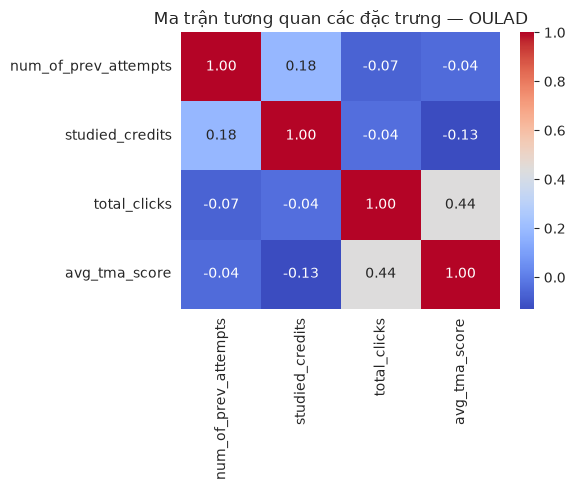

In [27]:
# ==== A5. Ma trận tương quan giữa các đặc trưng số (khám phá mối quan hệ dữ liệu) ====
numeric_cols_oulad = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'avg_tma_score']
corr_oulad = oulad[numeric_cols_oulad].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_oulad, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan các đặc trưng — OULAD')
plt.tight_layout()
plt.show()

In [28]:

feature_cols_oulad = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'avg_tma_score']

oulad_model_df = oulad.dropna(subset=['risk_level']).copy()

le_oulad = LabelEncoder()
oulad_model_df['risk_label_enc'] = le_oulad.fit_transform(oulad_model_df['risk_level'])  # A,B,C -> số

X_oulad = oulad_model_df[feature_cols_oulad]
y_oulad = oulad_model_df['risk_label_enc']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_oulad, y_oulad, test_size=0.2, random_state=RANDOM_STATE, stratify=y_oulad
)
print("Train:", X_train_o.shape, " Test:", X_test_o.shape)
print("Ánh xạ nhãn:", dict(zip(le_oulad.classes_, le_oulad.transform(le_oulad.classes_))))


Train: (26074, 4)  Test: (6519, 4)
Ánh xạ nhãn: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2)}


In [29]:
# ==== A7. Huấn luyện & đánh giá mô hình Random Forest và XGBoost trên OULAD ====
rf_oulad = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf_oulad.fit(X_train_o, y_train_o)
pred_rf_o = rf_oulad.predict(X_test_o)
xgb_oulad = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb_oulad.fit(X_train_o, y_train_o)
pred_xgb_o = xgb_oulad.predict(X_test_o)

print("=== Random Forest — OULAD ===")
print(classification_report(y_test_o, pred_rf_o, target_names=le_oulad.classes_))
print("=== XGBoost — OULAD ===")
print(classification_report(y_test_o, pred_xgb_o, target_names=le_oulad.classes_))

=== Random Forest — OULAD ===
              precision    recall  f1-score   support

           A       0.87      0.74      0.80      3442
           B       0.59      0.76      0.66      1234
           C       0.84      0.91      0.87      1843

    accuracy                           0.79      6519
   macro avg       0.77      0.80      0.78      6519
weighted avg       0.81      0.79      0.79      6519

=== XGBoost — OULAD ===
              precision    recall  f1-score   support

           A       0.84      0.82      0.83      3442
           B       0.65      0.67      0.66      1234
           C       0.87      0.90      0.88      1843

    accuracy                           0.81      6519
   macro avg       0.79      0.79      0.79      6519
weighted avg       0.81      0.81      0.81      6519



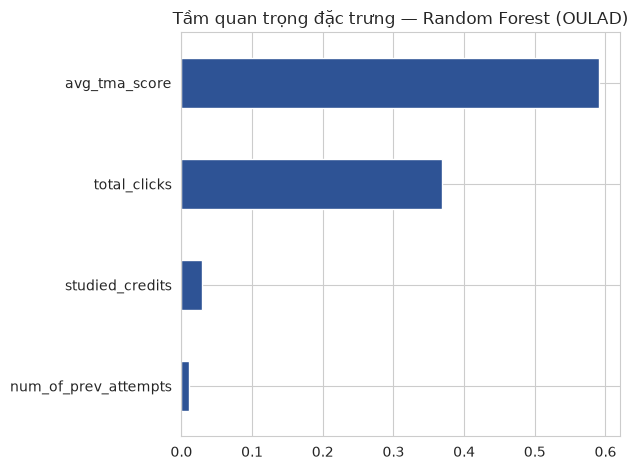

In [30]:
# ==== A8. Tầm quan trọng đặc trưng (feature importance) — OULAD ====
importances_o = pd.Series(rf_oulad.feature_importances_, index=feature_cols_oulad).sort_values()
importances_o.plot(kind='barh', title='Tầm quan trọng đặc trưng — Random Forest (OULAD)', color='#2E5395')
plt.tight_layout()
plt.show()


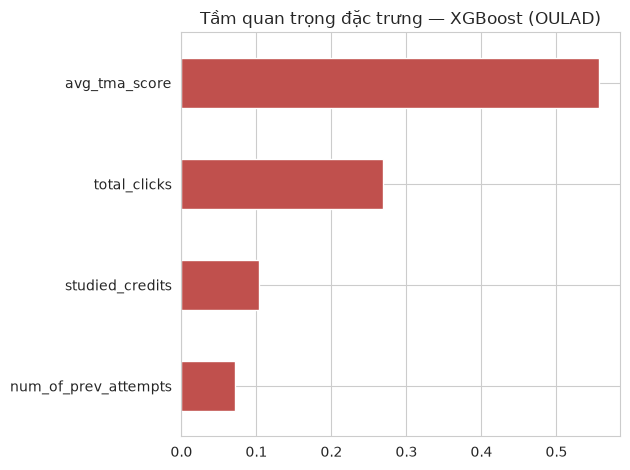

In [31]:
# So sánh thêm feature importance của XGBoost
importances_xgb_o = pd.Series(xgb_oulad.feature_importances_, index=feature_cols_oulad).sort_values()
importances_xgb_o.plot(kind='barh', title='Tầm quan trọng đặc trưng — XGBoost (OULAD)', color='#C0504D')
plt.tight_layout()
plt.show()

In [32]:
Phần B: BỘ DỮ LIỆU UCI (ID 697: Predict Students' Dropout and Academic Success)

SyntaxError: unterminated string literal (detected at line 1) (755511151.py, line 1)

In [33]:
# ==== B1. Tải dữ liệu UCI ID 697 ====
try:
    from ucimlrepo import fetch_ucirepo
    dataset = fetch_ucirepo(id=697)
    X_uci_raw = dataset.data.features
    y_uci_raw = dataset.data.targets
    uci = pd.concat([X_uci_raw, y_uci_raw], axis=1)
    print("Đã tải qua ucimlrepo.")
except Exception as e:
    print("Không tải được qua ucimlrepo, thử đọc từ file CSV đã tải sẵn. Lỗi:", e)
    uci = pd.read_csv("./uci_697/data.csv", sep=';')

print(uci.shape)
uci.head()

Đã tải qua ucimlrepo.
(4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Phân bố kết quả học tập (Target):
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


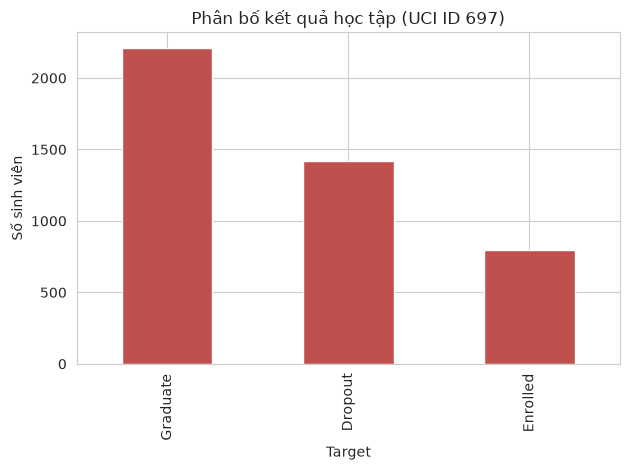


Tổng số giá trị thiếu: 0


In [34]:
# ==== B2. Khám phá dữ liệu (EDA) — UCI ====
print("Phân bố kết quả học tập (Target):")
print(uci['Target'].value_counts())

uci['Target'].value_counts().plot(kind='bar', title='Phân bố kết quả học tập (UCI ID 697)', color='#C0504D')
plt.ylabel('Số sinh viên')
plt.tight_layout()
plt.show()

print("\nTổng số giá trị thiếu:", uci.isnull().sum().sum())

In [35]:
# ==== B3. Gán nhãn 3 mức rủi ro A(Cao)/B(Trung bình)/C(Thấp), đồng bộ cách làm với OULAD ====
risk_map_uci = {
    'Dropout': 'A',   # Cao — đã bỏ học
    'Enrolled': 'B',  # Trung bình — vẫn đang học, chưa rõ kết quả cuối
    'Graduate': 'C'   # Thấp — đã tốt nghiệp
}
uci['risk_level'] = uci['Target'].map(risk_map_uci)
print(uci['risk_level'].value_counts())


risk_level
C    2209
A    1421
B     794
Name: count, dtype: int64


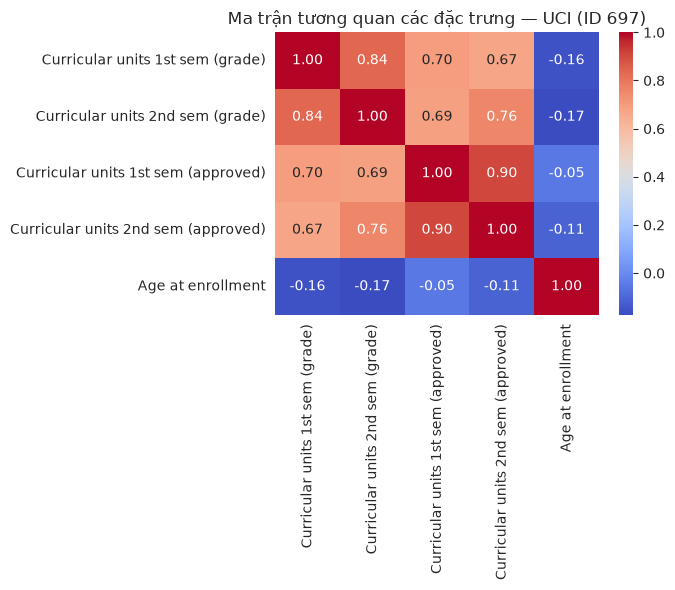

In [36]:
# ==== B4. Ma trận tương quan — UCI (chọn các đặc trưng liên quan trực tiếp đến kết quả học tập) ====
numeric_cols_uci = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Age at enrollment'
]
numeric_cols_uci = [c for c in numeric_cols_uci if c in uci.columns]

corr_uci = uci[numeric_cols_uci].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr_uci, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan các đặc trưng — UCI (ID 697)')
plt.tight_layout()
plt.show()

In [37]:
# ==== B5. Chuẩn bị & huấn luyện mô hình cho UCI ====
feature_cols_uci = numeric_cols_uci  # có thể mở rộng thêm khi đã xem hết 36 cột gốc

uci_model_df = uci.dropna(subset=['risk_level']).copy()
le_uci = LabelEncoder()
uci_model_df['risk_label_enc'] = le_uci.fit_transform(uci_model_df['risk_level'])

X_uci = uci_model_df[feature_cols_uci].fillna(0)
y_uci = uci_model_df['risk_label_enc']

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=RANDOM_STATE, stratify=y_uci
)

rf_uci = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf_uci.fit(X_train_u, y_train_u)
pred_rf_u = rf_uci.predict(X_test_u)

xgb_uci = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='mlogloss')
xgb_uci.fit(X_train_u, y_train_u)
pred_xgb_u = xgb_uci.predict(X_test_u)

print("=== Random Forest — UCI ===")
print(classification_report(y_test_u, pred_rf_u, target_names=le_uci.classes_))
print("=== XGBoost — UCI ===")
print(classification_report(y_test_u, pred_xgb_u, target_names=le_uci.classes_))

=== Random Forest — UCI ===
              precision    recall  f1-score   support

           A       0.67      0.68      0.68       284
           B       0.32      0.35      0.33       159
           C       0.79      0.76      0.78       442

    accuracy                           0.66       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.67      0.66      0.67       885

=== XGBoost — UCI ===
              precision    recall  f1-score   support

           A       0.67      0.70      0.69       284
           B       0.35      0.28      0.31       159
           C       0.78      0.81      0.80       442

    accuracy                           0.68       885
   macro avg       0.60      0.60      0.60       885
weighted avg       0.67      0.68      0.67       885



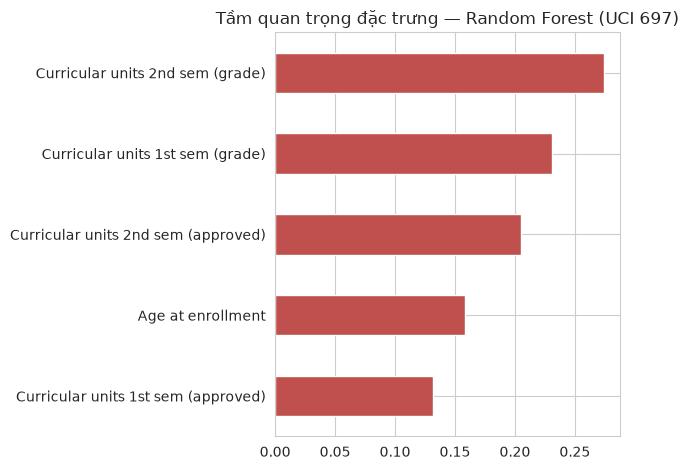

In [38]:
# ==== B6. Tầm quan trọng đặc trưng — UCI ====
importances_u = pd.Series(rf_uci.feature_importances_, index=feature_cols_uci).sort_values()
importances_u.plot(kind='barh', title='Tầm quan trọng đặc trưng — Random Forest (UCI 697)', color='#C0504D')
plt.tight_layout()
plt.show()

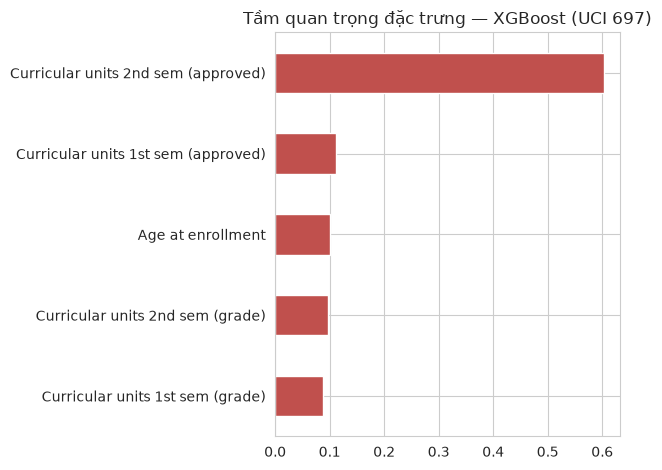

In [39]:
# ==== B7. Tầm quan trọng đặc trưng — XGBoost (UCI) ====
importances_xgb_u = pd.Series(xgb_uci.feature_importances_, index=feature_cols_uci).sort_values()
importances_xgb_u.plot(kind='barh', title='Tầm quan trọng đặc trưng — XGBoost (UCI 697)', color='#C0504D')
plt.tight_layout()
plt.show()

In [ ]:
Phần C:SO SÁNH & KIỂM ĐỊNH CHÉO GIỮA 2 BỘ DỮ LIỆU

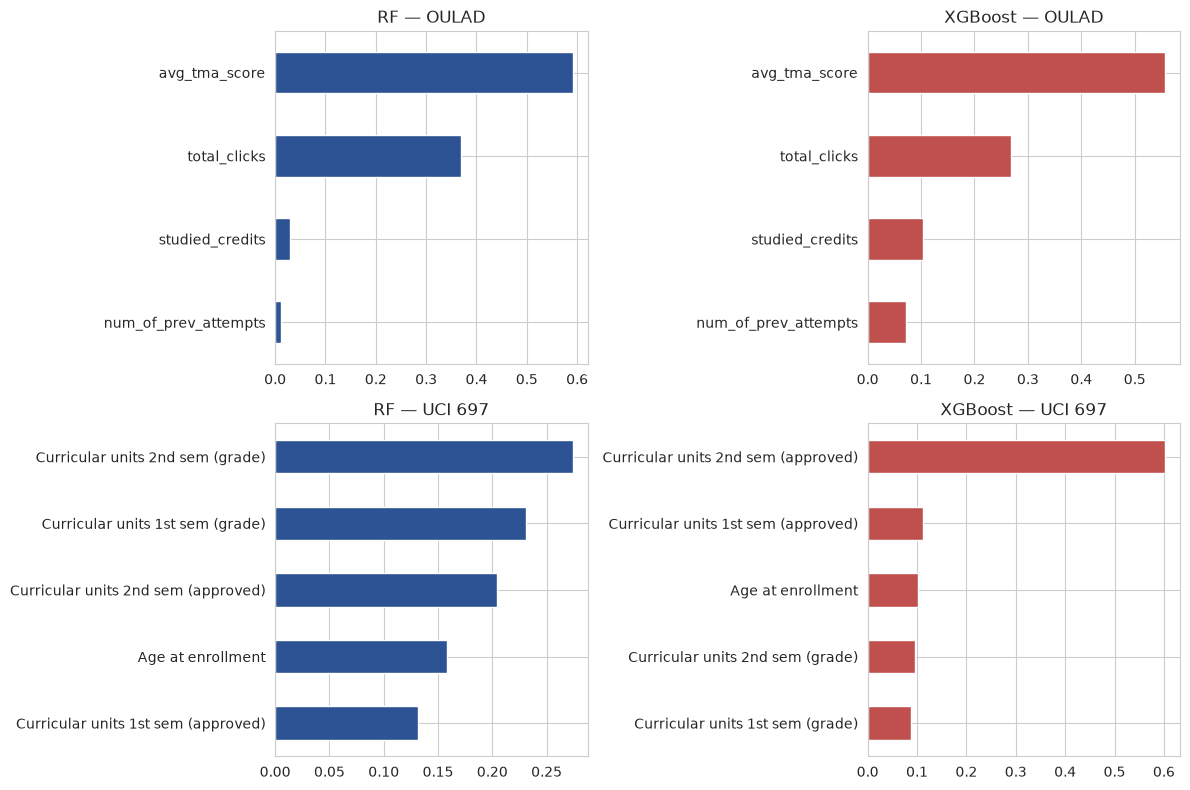

In [40]:
# ==== So sánh trực quan Feature Importance — cả 4 mô hình ====
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

pd.Series(rf_oulad.feature_importances_, index=feature_cols_oulad).sort_values().plot(
    kind='barh', ax=axes[0,0], color='#2E5395', title='RF — OULAD')
pd.Series(xgb_oulad.feature_importances_, index=feature_cols_oulad).sort_values().plot(
    kind='barh', ax=axes[0,1], color='#C0504D', title='XGBoost — OULAD')
pd.Series(rf_uci.feature_importances_, index=feature_cols_uci).sort_values().plot(
    kind='barh', ax=axes[1,0], color='#2E5395', title='RF — UCI 697')
pd.Series(xgb_uci.feature_importances_, index=feature_cols_uci).sort_values().plot(
    kind='barh', ax=axes[1,1], color='#C0504D', title='XGBoost — UCI 697')

plt.tight_layout()
plt.show()

In [41]:
# ==== C1. Xây tập đặc trưng khái niệm chung ====
common_oulad = oulad_model_df[['avg_tma_score', 'studied_credits', 'risk_label_enc']].copy()
common_oulad.columns = ['avg_score', 'credits_load', 'risk_label_enc']

common_uci = uci_model_df[['Curricular units 1st sem (grade)', 'Curricular units 1st sem (enrolled)', 'risk_label_enc']].copy()
common_uci.columns = ['avg_score', 'credits_load', 'risk_label_enc']

# Chuẩn hóa riêng từng bộ (thang điểm OULAD ~0-100, UCI ~0-20 -> cần đưa về cùng phân bố)
scaler_o = StandardScaler()
scaler_u = StandardScaler()
common_oulad[['avg_score', 'credits_load']] = scaler_o.fit_transform(common_oulad[['avg_score', 'credits_load']])
common_uci[['avg_score', 'credits_load']] = scaler_u.fit_transform(common_uci[['avg_score', 'credits_load']])

print("OULAD (đặc trưng chung):", common_oulad.shape)
print("UCI   (đặc trưng chung):", common_uci.shape)


OULAD (đặc trưng chung): (32593, 3)
UCI   (đặc trưng chung): (4424, 3)


In [42]:
# ==== C2. Kiểm định chéo (cross-dataset generalization) ====
X_common_o, y_common_o = common_oulad[['avg_score', 'credits_load']], common_oulad['risk_label_enc']
X_common_u, y_common_u = common_uci[['avg_score', 'credits_load']], common_uci['risk_label_enc']

# Chiều 1: huấn luyện trên OULAD -> kiểm định trên UCI
rf_cross1 = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf_cross1.fit(X_common_o, y_common_o)
pred_cross_on_uci = rf_cross1.predict(X_common_u)

print("=== Huấn luyện trên OULAD, kiểm định trên UCI ===")
print("Accuracy:", accuracy_score(y_common_u, pred_cross_on_uci))
print("F1 (macro):", f1_score(y_common_u, pred_cross_on_uci, average='macro'))

# Chiều 2: huấn luyện trên UCI -> kiểm định trên OULAD
rf_cross2 = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced')
rf_cross2.fit(X_common_u, y_common_u)
pred_cross_on_oulad = rf_cross2.predict(X_common_o)

print("\n=== Huấn luyện trên UCI, kiểm định trên OULAD ===")
print("Accuracy:", accuracy_score(y_common_o, pred_cross_on_oulad))
print("F1 (macro):", f1_score(y_common_o, pred_cross_on_oulad, average='macro'))

=== Huấn luyện trên OULAD, kiểm định trên UCI ===
Accuracy: 0.4315099457504521
F1 (macro): 0.43135729113617466

=== Huấn luyện trên UCI, kiểm định trên OULAD ===
Accuracy: 0.5385819040898352
F1 (macro): 0.47713385353636717


In [43]:
# ==== C3. Bảng tổng hợp so sánh toàn bộ kết quả ====
summary = pd.DataFrame({
    'Kịch bản': [
        'RF trên OULAD (nội bộ)', 'XGBoost trên OULAD (nội bộ)',
        'RF trên UCI (nội bộ)', 'XGBoost trên UCI (nội bộ)',
        'RF: train OULAD -> test UCI (chéo)',
        'RF: train UCI -> test OULAD (chéo)'
    ],
    'Accuracy': [
        accuracy_score(y_test_o, pred_rf_o),
        accuracy_score(y_test_o, pred_xgb_o),
        accuracy_score(y_test_u, pred_rf_u),
        accuracy_score(y_test_u, pred_xgb_u),
        accuracy_score(y_common_u, pred_cross_on_uci),
        accuracy_score(y_common_o, pred_cross_on_oulad),
    ],
    'F1 (macro)': [
        f1_score(y_test_o, pred_rf_o, average='macro'),
        f1_score(y_test_o, pred_xgb_o, average='macro'),
        f1_score(y_test_u, pred_rf_u, average='macro'),
        f1_score(y_test_u, pred_xgb_u, average='macro'),
        f1_score(y_common_u, pred_cross_on_uci, average='macro'),
        f1_score(y_common_o, pred_cross_on_oulad, average='macro'),
    ]
})
summary.round(4)

,Kịch bản,Accuracy,F1 (macro)
0,RF trên OULAD (nội bộ),0.7911,0.7780
1,XGBoost trên OULAD (nội bộ),0.8113,0.7897
2,RF trên UCI (nội bộ),0.6621,0.5959
3,XGBoost trên UCI (nội bộ),0.6825,0.5980
4,RF: train OULAD -> test UCI (chéo),0.4315,0.4314
5,RF: train UCI -> test OULAD (chéo),0.5386,0.4771
